In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

## Simulations

In [48]:
extent = 25
n_pixels = 96
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [49]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


In [50]:
mesh_dim = np.linspace(0, n_pixels, (n_pixels + 1) * upsample_factor)
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_gce_cart)
temp_gce_cart_upsampled = interp(mesh_dim, mesh_dim)

In [51]:
from models.scd import dnds

In [52]:
n_sim = 30000

prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [2., 20.0, 1.99, 1.99, 40.0, 4.99, 2., 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 6.0, 1.0], 
               [2., 1.5, 1.5, 1.5, 12.0, 6.0]]

temps_ps = np.array([temp_gce_cart, temp_dsk_cart])
temps_poiss = np.array([temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])

temps_ps_upsampled = []

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)

thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [53]:
from tqdm.notebook import tqdm

In [55]:
s_ary = np.logspace(-1, 2, 1000)
logs_ary = np.log10(s_ary)
dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
ds_ary = np.diff(s_for_ds_ary)

signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
dnds_ary = []

for idx_theta, theta in enumerate(tqdm(thetas)):

    idx_theta_ps = len(temps_poiss)
    
    for idx, temp_ps in enumerate(temps_ps):

        dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
        s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
        dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
        dnds_ary.append(dnds_ary_temp)
        idx_theta_ps += 6

        n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

        # Sample, accounting for dS factor for log-space sampling
        sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

        dist = temps_ps_upsampled[idx]
        dist /= dist.sum() 
        pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
        inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)),p=dist.reshape(-1),size=n_ps,replace=True)
        selections = pairs.reshape(-1, 2)[inds]
        hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]
        
        signal = np.random.poisson(gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.))

        b = signal.shape[0] // upsample_factor
        signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

        signal_ensemble[idx_theta, :, :] += signal_reshaped
        
        flux_fraction[idx_theta, idx] = signal_reshaped.mean()
        
    flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
    signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))
    
flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T

  0%|          | 0/30000 [00:00<?, ?it/s]

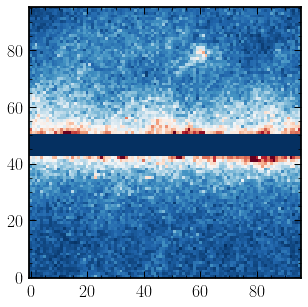

In [56]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

In [57]:
np.savez("data.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

## Generative model

In [58]:
data = np.load("data.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

from models.glow import Glow
from models.glow.module import GlowPL

In [60]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [61]:
x = torch.Tensor(signal_ensemble).unsqueeze(1)
y = torch.Tensor(flux_fraction)

In [62]:
# x = torch.Tensor(~mask_roi).unsqueeze(0).unsqueeze(0) * x

In [63]:
# x[x > 255.] = 0.
x.max()

tensor(2616.)

In [64]:
val_fraction = 0.15
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=16, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=16, pin_memory=True, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [65]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=16, quants=x.max() + 1)

In [73]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=12, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name | Type    | Params
---------------------------------
0 | flow | Glow    | 12.3 M
1 | loss | NLLLoss | 0     
---------------------------------
12.3 M    Trainable params
0         Non-trainable params
12.3 M    Total params
49.111    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [74]:
model.load_from_checkpoint(checkpoint_callback.best_model_path, num_channels=256, num_levels=5, num_steps=16, quants=x.max() + 1);

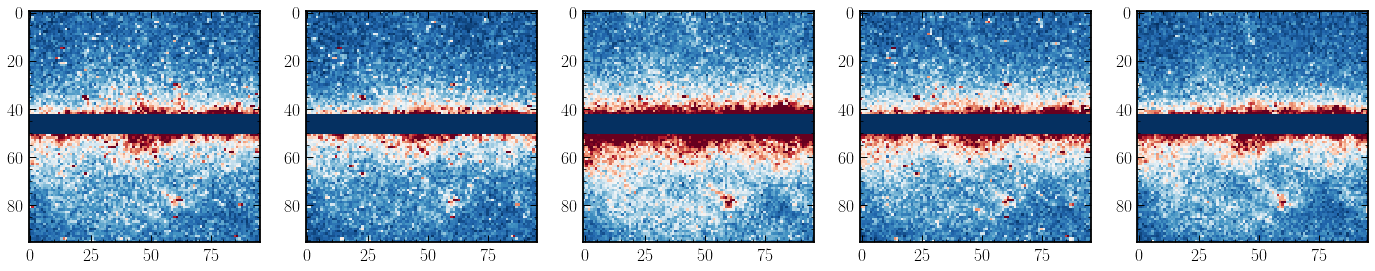

In [75]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi, cmap=cmap, vmax=50)

In [76]:
z = torch.randn(size=(5, 1, 96, 96))
x_samples, sldj = model.flow(z, reverse=True)

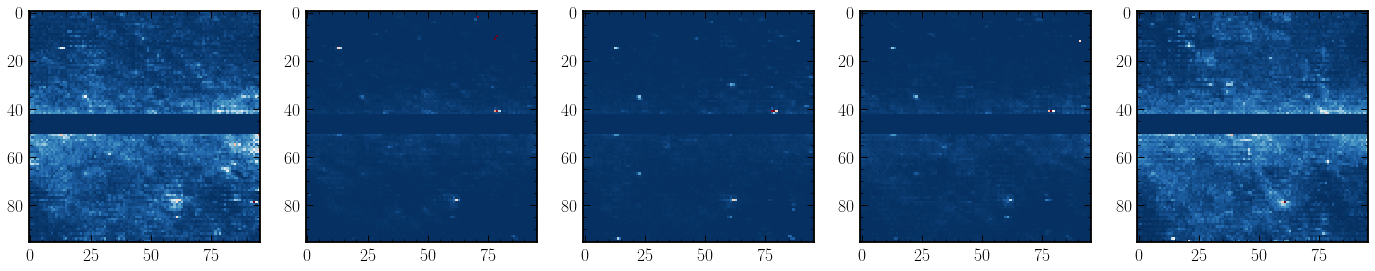

In [77]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi, cmap=cmap, vmax=50)